<a href="https://colab.research.google.com/github/turryhit/data-analytics-public/blob/main/DowJonesAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring FRED Data

We download the latest FRED DJIA data from https://fred.stlouisfed.org/series/DJIA in CSV format and load it into Pandas.

## Fetching the data

In [ ]:
URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=DJIA&scale=left&cosd=2021-03-23&coed=2026-03-23&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Daily%2C%20Close&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2026-03-24&revision_date=2026-03-24&nd=2016-03-24"

In [ ]:
import pandas as pd

df = pd.read_csv(URL)

In [ ]:
df

,observation_date,DJIA
0,2021-03-23,32423.15
1,2021-03-24,32420.06
2,2021-03-25,32619.48
3,2021-03-26,33072.88
4,2021-03-29,33171.37
...,...,...
1300,2026-03-17,46993.26
1301,2026-03-18,46225.15
1302,2026-03-19,46021.43
1303,2026-03-20,45577.47


## Analysis of code quality

In [ ]:
number_of_nulls = df.isnull().sum().sum()
print("There are " + str(number_of_nulls) + " null values")

There are 49 null values


In [ ]:
print("These are the columns with null values:")
df.isnull().sum()

These are the columns with null values:


,0
observation_date,0
DJIA,49


In [ ]:
num_rows = len(df)
null_ratio = number_of_nulls / num_rows
# We can use fstrings in Python to format our strings

print(f"{null_ratio * 100:.2f} % of the data is null")

3.75 % of the data is null


## We can create a graph to visualize the data

[Text(0.5, 1.0, 'DJIA over time')]

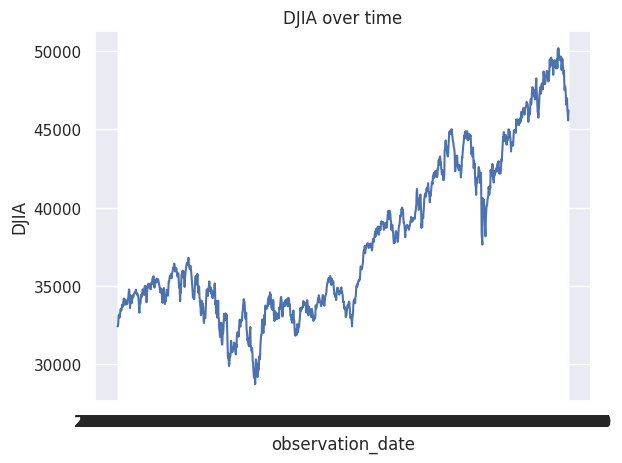

In [ ]:
import seaborn as sns

sns.set_theme()

ax = sns.lineplot(df, x="observation_date", y="DJIA")
ax.set(
    title="DJIA over time"
)

# Cleaning the data

In [ ]:
print(len(df))
print(len(df.dropna(axis=0, how='any')))
# We drop the rows that contain ANY NaN/null values
df = df.dropna(axis=0, how='any')
df

1305
1256


,observation_date,DJIA
0,2021-03-23,32423.15
1,2021-03-24,32420.06
2,2021-03-25,32619.48
3,2021-03-26,33072.88
4,2021-03-29,33171.37
...,...,...
1300,2026-03-17,46993.26
1301,2026-03-18,46225.15
1302,2026-03-19,46021.43
1303,2026-03-20,45577.47


# We can manipulate columns

In [ ]:
# We can create a new column
df["S&P"] = df["DJIA"] / 10

/tmp/ipykernel_91823/3800449464.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["S&P"] = df["DJIA"] / 10


In [ ]:
# We can drop the new column using df.drop
df.drop(["S&P"], axis=1, inplace=True)
# Is strictly equivalent to
# df = df.drop(["S&P"], axis=1)

/tmp/ipykernel_91823/470381945.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(["S&P"], axis=1, inplace=True)


In [ ]:
df

,observation_date,DJIA
0,2021-03-23,32423.15
1,2021-03-24,32420.06
2,2021-03-25,32619.48
3,2021-03-26,33072.88
4,2021-03-29,33171.37
...,...,...
1300,2026-03-17,46993.26
1301,2026-03-18,46225.15
1302,2026-03-19,46021.43
1303,2026-03-20,45577.47


# Creating the index

In [ ]:
df

,observation_date,DJIA
0,2021-03-23,32423.15
1,2021-03-24,32420.06
2,2021-03-25,32619.48
3,2021-03-26,33072.88
4,2021-03-29,33171.37
...,...,...
1300,2026-03-17,46993.26
1301,2026-03-18,46225.15
1302,2026-03-19,46021.43
1303,2026-03-20,45577.47


In [ ]:
# By default, we have an index that represents the ORIGINAL row position
# We can access specific rows either by:

# 1. Using .iloc, which is the POSITION in the dataframe. Here, since the dataframe
# has 1256 rows, the last POSITION is 1255 (start counting at 0)
df.iloc[1255]

# 2. Using .loc, which is the NAME of the index in the dataframe. Here, the last row
# has the index value 1304
df.loc[1304]

,1304
observation_date,2026-03-23
DJIA,46208.47


In [ ]:
# We can view the index of the DataFrame by using df.index
df.index
# We can cast it to a list if we need to
index_as_a_list = list(df.index)

In [ ]:
# We want to set the column observation_date as the index.
# We can first check to see if it's unique (all the values in it are unique)
df["observation_date"].is_unique

True

In [ ]:
# We can set the new index, since observation_date values are unique
df = df.set_index("observation_date")

# You can always undo this using
# df.reset_index() # Careful, this will start the new index from 0 and not remember dropped rows

KeyError: "None of ['observation_date'] are in the columns"

In [ ]:
# We can now use .loc[] to reference by date
df.loc["2024-03-22"]

,2024-03-22
DJIA,39475.9


In [ ]:
# We can see our new index
df.index

Index(['2021-03-23', '2021-03-24', '2021-03-25', '2021-03-26', '2021-03-29',
       '2021-03-30', '2021-03-31', '2021-04-01', '2021-04-05', '2021-04-06',
       ...
       '2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13', '2026-03-16',
       '2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20', '2026-03-23'],
      dtype='object', name='observation_date', length=1256)

In [ ]:
# We can convert our index from a type string to a type datetime
df.index = pd.to_datetime(df.index)

In [ ]:
df.index

DatetimeIndex(['2021-03-23', '2021-03-24', '2021-03-25', '2021-03-26',
               '2021-03-29', '2021-03-30', '2021-03-31', '2021-04-01',
               '2021-04-05', '2021-04-06',
               ...
               '2026-03-10', '2026-03-11', '2026-03-12', '2026-03-13',
               '2026-03-16', '2026-03-17', '2026-03-18', '2026-03-19',
               '2026-03-20', '2026-03-23'],
              dtype='datetime64[ns]', name='observation_date', length=1256, freq=None)

In [ ]:
# Now that we have DateTimeIndex, we can do some easy date filtering
# For example, we can filter our dataframe for a given year
df.loc["2026"]
# Or we can use datetime attributes to filter using our index
df[df.index.day_of_week == 4]

,DJIA
observation_date,
2021-03-26,33072.88
2021-04-09,33800.60
2021-04-16,34200.67
2021-04-23,34043.49
2021-04-30,33874.85
...,...
2026-02-20,49625.97
2026-02-27,48977.92
2026-03-06,47501.55


<Axes: xlabel='observation_date', ylabel='DJIA'>

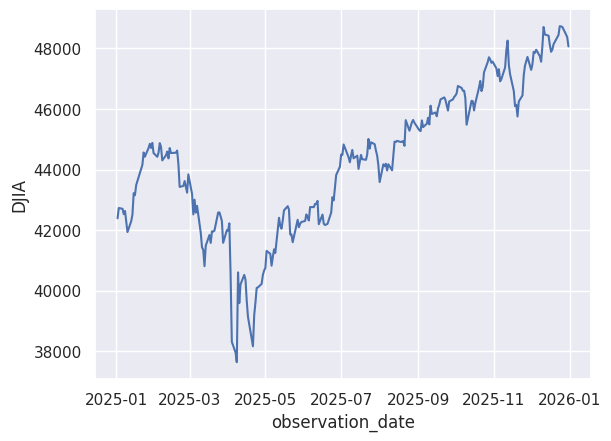

In [ ]:
sns.lineplot(df.loc["2025"], x=df.loc["2025"].index, y="DJIA")